# Problem 3: Traffic Sign Classification & Interpretability

We train a ResNet-18 from scratch, find a systemic failure on **speed limit** signs, explain it with saliency & occlusion, then fix it via a simple border-drop augmentation and demonstrate the improved results.

### Tasks
1. (3a) Interpretability methods (local & global)
2. (3b) Train ResNet-18 (80/20 stratified split)
3. (3c) Quantitative evaluation on validation & held-out test
4. (3d–e) Saliency & occlusion for failing class
5. (3f) Implement border-drop augmentation
6. (3g–h) Retrain & re-evaluate with interpretation

## (3a) Interpretability Methods

**Local explanation – Class Saliency Maps** (Simonyan et al.)
- Compute ∂score_true_class/∂pixel
- Pixels whose small change would most reduce the class score light up

**Global explanation – Occlusion Analysis**
- Slide a small zero patch across the image
- Record the drop in the predicted-class logit when each region is occluded
- Regions causing the largest drop are those the model “relies on.”

In [2]:
# Imports & setup
import os, gc, random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import random_split, DataLoader
import torchvision
from torchvision.transforms import v2
from torchvision.models import resnet18
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Project utilities
from src.utils import (
    load_images_as_numpy, compute_npz_mean_std,
    set_seed, create_dataloaders
)
from src.train import train_model
from src.evaluation import (
    classification_summary, plot_per_class_accuracy, plot_confusion_matrix, plot_predictions
)

# Device & cleanup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gc.collect(); torch.cuda.empty_cache() #  clear python garbage collector and cuda cache

# set number of workers for data loading
num_workers = os.cpu_count() - 1 if os.cpu_count() > 1 else 0 # in case of 1 core, set to 0

## (3b) Data Preparation & Baseline Transform

1. Compute mean/std on raw images
2. Define baseline transform: resize + normalize

In [3]:
train_path = 'data/problem3/train'
# 1) load as numpy & compute mean/std
raw_np = load_images_as_numpy(train_path)
t_mean, t_std = compute_npz_mean_std(raw_np)
print(f'Mean = {t_mean}, STD = {t_std}')


# 2) baseline transforms for training the baseline model
baseline_tf = v2.Compose([
    v2.Resize((224,224)), # Resize to 224x224 for ResNet18
    v2.ToImage(), # Convert to PIL Image
    v2.ToDtype(torch.float32, scale=True), # Convert to float32 and scale to [0, 1]
    v2.Normalize(mean=t_mean.tolist(), std=t_std.tolist()), # Normalize with computed mean and std
])

Computed mean: [0.06081618 0.06081618 0.06081618]
Computed std: [0.24660936 0.24660936 0.24660936]
Mean = [0.06081618 0.06081618 0.06081618], STD = [0.24660936 0.24660936 0.24660936]


### Build Dataloaders (80/20 stratified split)

In [4]:
full_ds = torchvision.datasets.ImageFolder(train_path, transform=baseline_tf)
set_seed(42)
n = len(full_ds); n_train = int(0.8 * n) # 80% for training, 20% for validation
# stratified split to ensure class balance in train/val sets
train_ds, val_ds = random_split(full_ds, [n_train, n - n_train]) # the random_split function will shuffle the dataset, so this is the stratified split

dls = create_dataloaders(
    train_ds, val_ds,
    batch_size=32, num_workers=num_workers, pin_memory=True,
    mode='both', shuffle_train=True, shuffle_val=False
)

class_names = full_ds.classes
print('Classes =', class_names)

Classes = ['restriction signs', 'speed limits', 'stop signs', 'warning signs', 'yield signs']


## (3b) Train ResNet-18 Baseline

Training resnet18_baseline_20250428_091819: 100%|██████████| 5190/5190 [06:39<00:00, 13.01batch/s, epoch=30/30, phase=val, loss=0.0010, acc=1.0000]  



Best Val Accuracy: 1.0000
Total training time: 399.06s


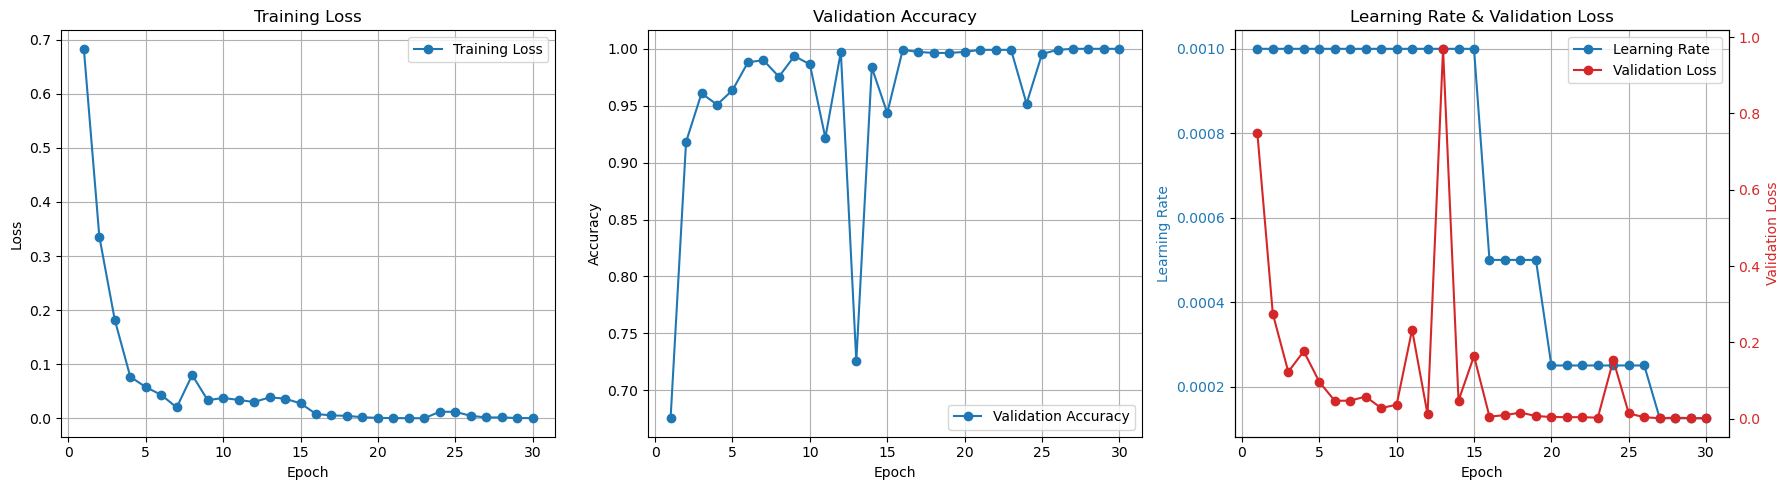

In [8]:
model = resnet18(weights=None, num_classes=len(class_names)).to(device) # no pretrained weights, num_classes = number of classes in the dataset
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2) # 

model, model_name = train_model(
    model, 
    dls, 
    criterion, 
    optimizer,
    scheduler=scheduler, 
    num_epochs=30,  # 30 epochs just to get a baseline for evaluation 
    model_name='resnet18_baseline'
)

## (3c) Quantitative Evaluation

Evaluate on the 20% validation split and the held-out `test` folder.

In [5]:
# prepare test loader
test_ds = torchvision.datasets.ImageFolder('data/problem3/test', transform=baseline_tf)
test_dl = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=num_workers, pin_memory=True)

test_dl = create_dataloaders(
    None,  # No training data needed for test set
    test_ds,
    batch_size=32,
    num_workers=num_workers,
    pin_memory=True,
    mode='val',
    shuffle_train=False,
    shuffle_val=False
)

# TESTING

In [13]:
# load a model 
torch.cuda.empty_cache() # clear cuda cache
model = resnet18(weights=None, num_classes=len(class_names)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2) # 
model.load_state_dict(torch.load('models/resnet18_baseline_20250428_091819_best.pth')) # load the model weights

model.eval() # set the model to evaluation mode

# evaluate the model on the test set

vl,vs,yv,pv = classification_summary(model, test_dl['val'], criterion,device) # get the validation loss and accuracy

C:\Users\tihas\AppData\Local\Temp\ipykernel_11260\380886658.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('models/resnet18_baseline_20

              precision    recall  f1-score   support

           0       0.87      0.99      0.92       163
           1       1.00      0.09      0.17       502
           2       1.00      1.00      1.00       597
           3       0.70      1.00      0.82      1007
           4       0.94      1.00      0.97        88

    accuracy                           0.80      2357
   macro avg       0.90      0.82      0.78      2357
weighted avg       0.86      0.80      0.74      2357



In [34]:
def iter_occlusion(image, size=8):
    occlusion = np.full((size * 5, size * 5, 1), 0.5, np.float32)
    occlusion_center = np.full((size, size, 1), 0.5, np.float32)
    occlusion_padding = size * 2

    # Pad the image
    image_padded = np.pad(image,
                          ((occlusion_padding, occlusion_padding),
                           (occlusion_padding, occlusion_padding),
                           (0, 0)),
                          'constant', constant_values=0.0)

    # Determine max y and x to ensure the occlusion patch fully fits
    max_y = image.shape[0] + occlusion_padding - occlusion_center.shape[0]
    max_x = image.shape[1] + occlusion_padding - occlusion_center.shape[1]

    for y in range(occlusion_padding, max_y + 1, size):
        for x in range(occlusion_padding, max_x + 1, size):
            tmp = image_padded.copy()

            tmp[y - occlusion_padding : y + occlusion_center.shape[0] + occlusion_padding,
                x - occlusion_padding : x + occlusion_center.shape[1] + occlusion_padding] = occlusion

            tmp[y : y + occlusion_center.shape[0],
                x : x + occlusion_center.shape[1]] = occlusion_center

            yield x - occlusion_padding, y - occlusion_padding, \
                  tmp[occlusion_padding:tmp.shape[0] - occlusion_padding,
                      occlusion_padding:tmp.shape[1] - occlusion_padding]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.18300158..3.8083868].


Label = 2
Correct class = stop signs
Input tensor shape = torch.Size([1, 3, 224, 224])


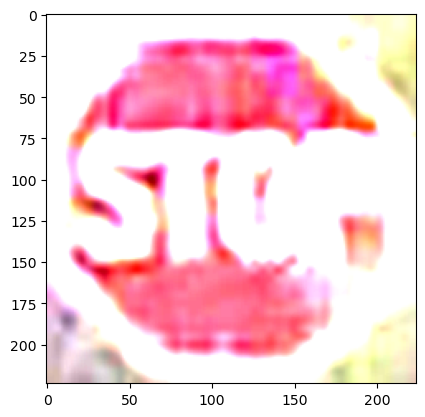

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.18300158..3.8083868].


Label = 2
Correct class = stop signs
Input tensor shape = torch.Size([1, 3, 224, 224])


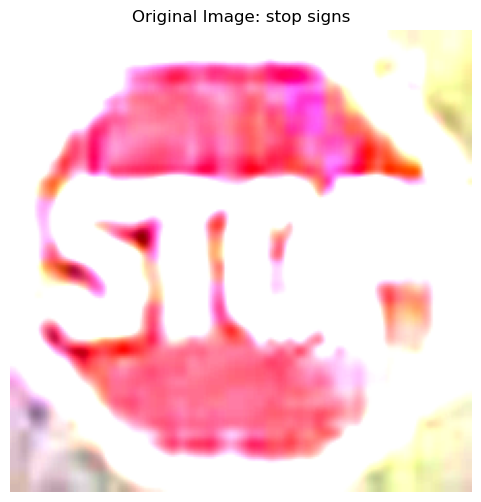

Original prediction: stop signs (confidence: 1.0000)
Running occlusion analysis...
Processing occlusion 0...
Processing occlusion 50...
Processing occlusion 100...
Processing occlusion 150...
Processing occlusion 200...
Processing occlusion 250...
Processing occlusion 300...
Processing occlusion 350...
Processing occlusion 400...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.18300158..3.8083868].


Processing occlusion 450...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.18300158..3.8083868].


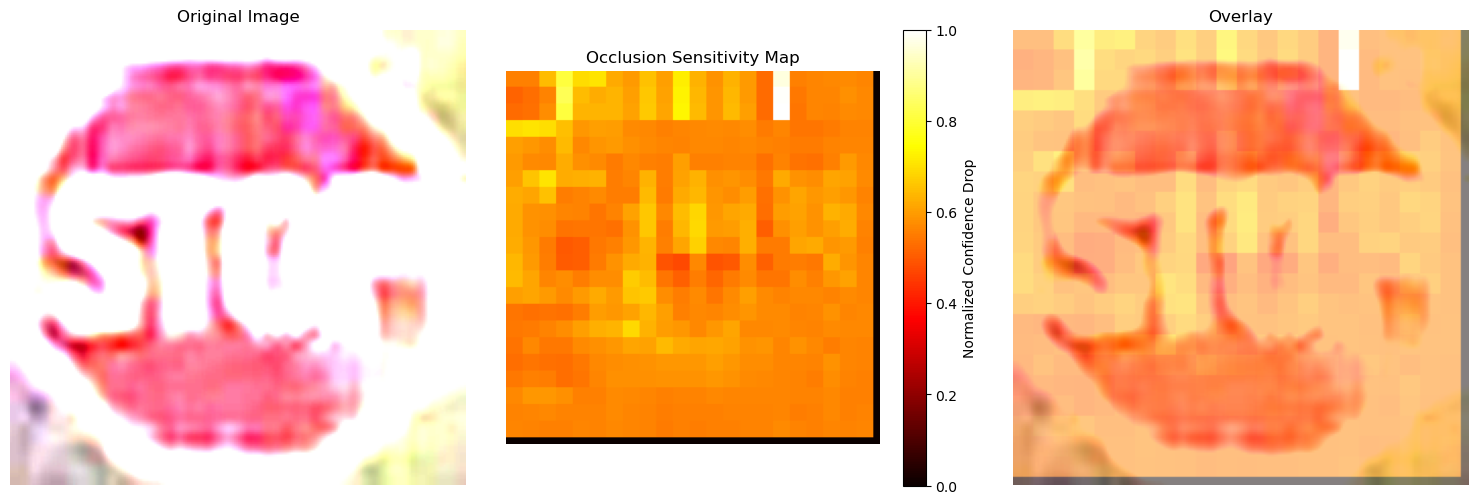

Correct class: stop signs
Model prediction: speed limits (confidence: 0.0000)

Prediction distribution during occlusion:
speed limits: 465 occurrences (96.07%)
warning signs: 19 occurrences (3.93%)


In [46]:
# Choose a sample from the training set
i = 1
data = train_ds[i][0]  # get the image from the training set
label = train_ds[i][1]  # get the label of the image
print('Label =', label)
print('Correct class =', class_names[label])

# Input tensor for model prediction
input_tensor = data.unsqueeze(0).to(device)
print('Input tensor shape =', input_tensor.shape)

# Original image data for display
img = data.permute(1, 2, 0).cpu().numpy()  # Move to CPU and permute to HWC format for imshow

# Display the original image
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Original Image: {class_names[label]}")
plt.axis('off')
plt.show()

# Get original prediction without occlusion
model.eval()
with torch.no_grad():
    original_pred = model(input_tensor).cpu().numpy()
    original_prob = np.exp(original_pred) / np.sum(np.exp(original_pred))
    pred_class = np.argmax(original_pred[0])
    
print(f"Original prediction: {class_names[pred_class]} (confidence: {original_prob[0][pred_class]:.4f})")

# Occlusion parameters
img_size = 224  # Size of the image
occlusion_size = 10  # Size of the occlusion patch

print('Running occlusion analysis...')

# Create heatmap to store importance of each region
heatmap = np.zeros((img_size, img_size), np.float32)

# Store the predicted class for each occluded region
class_pixels = np.zeros((img_size, img_size), np.int16)

# Keep track of prediction counts
from collections import defaultdict
counters = defaultdict(int)

# Run occlusion analysis
for n, (x, y, occluded_img) in enumerate(iter_occlusion(img, size=occlusion_size)):
    if n % 50 == 0:
        print(f'Processing occlusion {n}...')
        
    # Convert the occluded image to a tensor and normalize it
    occluded_tensor = torch.from_numpy(occluded_img).permute(2, 0, 1).float()
    occluded_tensor = baseline_tf(occluded_tensor).unsqueeze(0).to(device)
    
    # Get model prediction for occluded image
    with torch.no_grad():
        occluded_pred = model(occluded_tensor).cpu().numpy()
        
    # Store the change in confidence for the correct class
    confidence_drop = original_pred[0][label] - occluded_pred[0][label]
    heatmap[y:y + occlusion_size, x:x + occlusion_size] = confidence_drop
    
    # Store the predicted class for this occluded region
    pred_class = np.argmax(occluded_pred[0])
    class_pixels[y:y + occlusion_size, x:x + occlusion_size] = pred_class
    counters[pred_class] += 1

# Normalize the heatmap for better visualization
heatmap_normalized = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

# Plot the results
plt.figure(figsize=(15, 5))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

# Heatmap
plt.subplot(1, 3, 2)
plt.imshow(heatmap_normalized, cmap='hot')
plt.title("Occlusion Sensitivity Map")
plt.colorbar(label='Normalized Confidence Drop')
plt.axis('off')

# Overlay heatmap on original image
plt.subplot(1, 3, 3)
plt.imshow(img)
plt.imshow(heatmap_normalized, cmap='hot', alpha=0.5)
plt.title("Overlay")
plt.axis('off')

plt.tight_layout()
plt.show()

# Show prediction statistics
print(f"Correct class: {class_names[label]}")
print(f"Model prediction: {class_names[pred_class]} (confidence: {original_prob[0][pred_class]:.4f})")

print("\nPrediction distribution during occlusion:")
for class_id, count in sorted(counters.items(), key=lambda x: -x[1]):
    percentage = (count / sum(counters.values())) * 100
    print(f"{class_names[class_id]}: {count} occurrences ({percentage:.2f}%)")

C:\Users\tihas\AppData\Local\Temp\ipykernel_11260\3077004001.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  custom = cm.get_cmap('tab10', len(bounds)) # using tab10 for clearer distinction


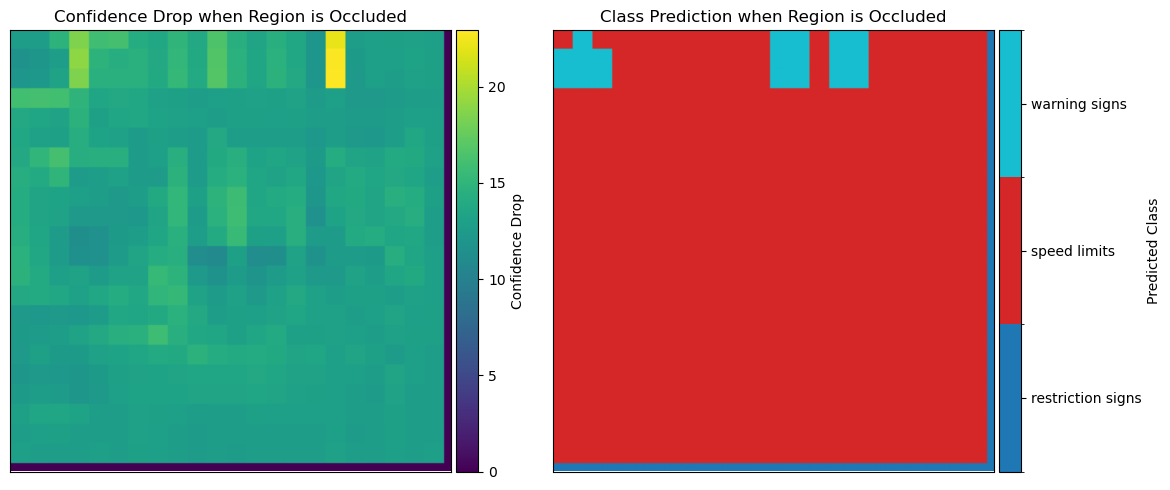

Original image class: stop signs

Most predicted classes during occlusion:
speed limits: 465 occurrences (96.07%)
warning signs: 19 occurrences (3.93%)


In [48]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import BoundaryNorm
from matplotlib.colorbar import ColorbarBase
from matplotlib import cm

fig = plt.figure(figsize=(12, 5))

# First subplot - heatmap showing confidence drop
ax1 = plt.subplot(1, 2, 1, aspect='equal')
hm = ax1.imshow(heatmap)
ax1.set_title("Confidence Drop when Region is Occluded")
ax1.set_xticks([])
ax1.set_yticks([])

# Second subplot - class prediction when region is occluded
ax2 = plt.subplot(1, 2, 2, aspect='equal')
vals = np.unique(class_pixels).tolist()
bounds = vals + [vals[-1] + 1]  # add an extra item for the colormap boundaries

# Create a custom colormap with distinct colors for each class
custom = cm.get_cmap('tab10', len(bounds)) # using tab10 for clearer distinction
norm = BoundaryNorm(bounds, custom.N)

cp = ax2.imshow(class_pixels, norm=norm, cmap=custom)
ax2.set_title("Class Prediction when Region is Occluded")
ax2.set_xticks([])
ax2.set_yticks([])

# Add colorbar for the heatmap
divider = make_axes_locatable(ax1)
cax1 = divider.append_axes("right", size="5%", pad=0.05)
cbar1 = plt.colorbar(hm, cax=cax1)
cbar1.set_label('Confidence Drop')

# Add colorbar for the class predictions
divider = make_axes_locatable(ax2)
cax2 = divider.append_axes("right", size="5%", pad=0.05)
cbar2 = ColorbarBase(cax2, cmap=custom, norm=norm,
                    ticks=[(a + b) / 2.0 for a, b in zip(bounds[:-1], bounds[1:])],
                    boundaries=bounds, spacing='uniform', orientation='vertical')

# Set the labels for each class in the colorbar
class_labels = [class_names[i] if i < len(class_names) else f"Class {i}" for i in vals]
cbar2.ax.set_yticklabels(class_labels)
cbar2.set_label('Predicted Class')

plt.tight_layout()
plt.show()

# Print summary of confidence drop and class predictions
print(f"Original image class: {class_names[label]}")
print("\nMost predicted classes during occlusion:")
for class_id, count in sorted(counters.items(), key=lambda x: -x[1]):
    percentage = (count / sum(counters.values())) * 100
    print(f"{class_names[class_id]}: {count} occurrences ({percentage:.2f}%)")

In [ ]:
def visualize_occlusion_analysis(model, image_tensor, label, class_names, occlusion_size=10, baseline_tf=None, device='cuda'):
    """
    Performs occlusion analysis on an image and visualizes the results.
    
    Args:
        model: PyTorch model
        image_tensor: Input image tensor (CxHxW)
        label: True label index
        class_names: List of class names
        occlusion_size: Size of the occlusion patch
        baseline_tf: Transform to apply to occluded images
        device: Device to run model on ('cuda' or 'cpu')
    
    Returns:
        heatmap: Confidence drop heatmap
        class_pixels: Class prediction map
        counters: Dictionary counting class predictions during occlusion
    """
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    from matplotlib.colors import BoundaryNorm
    from matplotlib.colorbar import ColorbarBase
    from matplotlib import cm
    from collections import defaultdict
    import numpy as np
    import torch
    import matplotlib.pyplot as plt
    
    # Input tensor for model prediction
    input_tensor = image_tensor.unsqueeze(0).to(device)
    
    # Original image data for display
    img = image_tensor.permute(1, 2, 0).cpu().numpy()  # Move to CPU and permute to HWC format for imshow
    
    # Display the original image
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Original Image: {class_names[label]}")
    plt.axis('off')
    plt.show()
    
    # Get original prediction without occlusion
    model.eval()
    with torch.no_grad():
        original_pred = model(input_tensor).cpu().numpy()
        original_prob = np.exp(original_pred) / np.sum(np.exp(original_pred))
        pred_class = np.argmax(original_pred[0])
        
    print(f"Original prediction: {class_names[pred_class]} (confidence: {original_prob[0][pred_class]:.4f})")
    
    # Image dimensions
    img_size = img.shape[0]  # Size of the image
    
    print('Running occlusion analysis...')
    
    # Create heatmap to store importance of each region
    heatmap = np.zeros((img_size, img_size), np.float32)
    
    # Store the predicted class for each occluded region
    class_pixels = np.zeros((img_size, img_size), np.int16)
    
    # Keep track of prediction counts
    counters = defaultdict(int)
    
    # Run occlusion analysis
    for n, (x, y, occluded_img) in enumerate(iter_occlusion(img, size=occlusion_size)):
        if n % 50 == 0:
            print(f'Processing occlusion {n}...')
            
        # Convert the occluded image to a tensor and normalize it
        occluded_tensor = torch.from_numpy(occluded_img).permute(2, 0, 1).float()
        if baseline_tf:
            occluded_tensor = baseline_tf(occluded_tensor)
        occluded_tensor = occluded_tensor.unsqueeze(0).to(device)
        
        # Get model prediction for occluded image
        with torch.no_grad():
            occluded_pred = model(occluded_tensor).cpu().numpy()
            
        # Store the change in confidence for the correct class
        confidence_drop = original_pred[0][label] - occluded_pred[0][label]
        heatmap[y:y + occlusion_size, x:x + occlusion_size] = confidence_drop
        
        # Store the predicted class for this occluded region
        pred_class = np.argmax(occluded_pred[0])
        class_pixels[y:y + occlusion_size, x:x + occlusion_size] = pred_class
        counters[pred_class] += 1
    
    # Normalize the heatmap for better visualization
    heatmap_normalized = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    
    # Plot the results
    plt.figure(figsize=(15, 5))
    
    # Original image
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')
    
    # Heatmap
    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_normalized, cmap='hot')
    plt.title("Occlusion Sensitivity Map")
    plt.colorbar(label='Normalized Confidence Drop')
    plt.axis('off')
    
    # Overlay heatmap on original image
    plt.subplot(1, 3, 3)
    plt.imshow(img)
    plt.imshow(heatmap_normalized, cmap='hot', alpha=0.5)
    plt.title("Overlay")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Create detailed visualization
    fig = plt.figure(figsize=(12, 5))
    
    # First subplot - heatmap showing confidence drop
    ax1 = plt.subplot(1, 2, 1, aspect='equal')
    hm = ax1.imshow(heatmap)
    ax1.set_title("Confidence Drop when Region is Occluded")
    ax1.set_xticks([])
    ax1.set_yticks([])
    
    # Second subplot - class prediction when region is occluded
    ax2 = plt.subplot(1, 2, 2, aspect='equal')
    vals = np.unique(class_pixels).tolist()
    bounds = vals + [vals[-1] + 1]  # add an extra item for the colormap boundaries
    
    # Create a custom colormap with distinct colors for each class
    custom = cm.get_cmap('tab10', len(bounds)) # using tab10 for clearer distinction
    norm = BoundaryNorm(bounds, custom.N)
    
    cp = ax2.imshow(class_pixels, norm=norm, cmap=custom)
    ax2.set_title("Class Prediction when Region is Occluded")
    ax2.set_xticks([])
    ax2.set_yticks([])
    
    # Add colorbar for the heatmap
    divider = make_axes_locatable(ax1)
    cax1 = divider.append_axes("right", size="5%", pad=0.05)
    cbar1 = plt.colorbar(hm, cax=cax1)
    cbar1.set_label('Confidence Drop')
    
    # Add colorbar for the class predictions
    divider = make_axes_locatable(ax2)
    cax2 = divider.append_axes("right", size="5%", pad=0.05)
    cbar2 = ColorbarBase(cax2, cmap=custom, norm=norm,
                        ticks=[(a + b) / 2.0 for a, b in zip(bounds[:-1], bounds[1:])],
                        boundaries=bounds, spacing='uniform', orientation='vertical')
    
    # Set the labels for each class in the colorbar
    class_labels = [class_names[i] if i < len(class_names) else f"Class {i}" for i in vals]
    cbar2.ax.set_yticklabels(class_labels)
    cbar2.set_label('Predicted Class')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary of confidence drop and class predictions
    print(f"Original image class: {class_names[label]}")
    print("\nMost predicted classes during occlusion:")
    for class_id, count in sorted(counters.items(), key=lambda x: -x[1]):
        percentage = (count / sum(counters.values())) * 100
        print(f"{class_names[class_id]}: {count} occurrences ({percentage:.2f}%)")
        
    return heatmap, class_pixels, counters

: 